In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc 
from sklearn.metrics import f1_score
import json

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_gait import *
from src.plot_data_gait import *
from src.train_LSTMGait import train_model, predict_trial

In [2]:
base_path = '../datasets/GAIT_signals/dataset/data'

# Training

## RAW + WIN-NORM

In [3]:
ckpt_path = "../checkpoints/raw_win_norm"

In [4]:
X, y, subjects = load_dataset_gait(base_path, process="raw", sensors=["LB"], window_size=200, stride=50)
X = X.astype(np.float32)
y = y.astype(np.int64)

In [5]:
trained_model, best_val_f1, test_f1 = train_model(X, y, subjects, model_name="cnnbilstm", norm="window", epochs=200, lr=0.0003, patience=20, out_dir=ckpt_path)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 42. Best F1: 0.8579

Val F1: 0.8579  |  Test F1: 0.8645
Checkpoint saved → ../checkpoints/raw_win_norm/model.pt


## RAW + TRIAL-NORM

In [6]:
ckpt_path = "../checkpoints/raw_trial_norm"

In [7]:
trained_model, best_val_f1, test_f1 = train_model(X, y, subjects, model_name="cnnbilstm", norm="subj", epochs=200, lr=0.0003, patience=20, out_dir=ckpt_path)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 26. Best F1: 0.8447

Val F1: 0.8447  |  Test F1: 0.8452
Checkpoint saved → ../checkpoints/raw_trial_norm/model.pt


## RAW-GRAVITY-CORRECTION + WIN-NORM

In [8]:
ckpt_path = "../checkpoints/raw_gravity_correct_win_norm"

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=["LB"], window_size=200, stride=50) #probar de 1s-7s y de 0 a 100% de stride 
X = X.astype(np.float32)
y = y.astype(np.int64)

In [10]:
trained_model, best_val_f1, test_f1 = train_model(X, y, subjects, model_name="cnnbilstm", norm="window", epochs=200, lr=0.0003, patience=20, out_dir=ckpt_path)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 29. Best F1: 0.8320

Val F1: 0.8320  |  Test F1: 0.8159
Checkpoint saved → ../checkpoints/raw_gravity_correct_win_norm/model.pt


## RAW-GRAVITY-CORRECTION + TRIAL-NORM

In [11]:
ckpt_path = "../checkpoints/raw_gravity_correct_trial_norm"

In [12]:
trained_model, best_val_f1, test_f1 = train_model(X, y, subjects, model_name="cnnbilstm", norm="subj", epochs=200, lr=0.0003, patience=20, out_dir=ckpt_path)

Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 32. Best F1: 0.8215

Val F1: 0.8215  |  Test F1: 0.8060
Checkpoint saved → ../checkpoints/raw_gravity_correct_trial_norm/model.pt


# Analysis

Model: CNN + BiLSTM (window norm) | Sensor: Back Sensor
         val_f1   test_f1
count  260.0000  260.0000
mean     0.8810    0.8663
std      0.0127    0.1158
min      0.8483    0.2657
25%      0.8776    0.8356
50%      0.8836    0.9087
75%      0.8899    0.9358
max      0.9013    0.9617

Test F1 Median: 0.9087
Mean Test F1 : 0.8663 ± 0.1158
\Per cohort:
        mean  median    std  count
group                             
HOA    0.826   0.895  0.187     15
RIL    0.847   0.912  0.146     51
HS     0.862   0.890  0.091     73
CVA    0.869   0.901  0.105     49
KOA    0.878   0.919  0.088     18
PD     0.880   0.924  0.123     24
ACL    0.885   0.907  0.077     11
CIPN   0.920   0.944  0.092     19


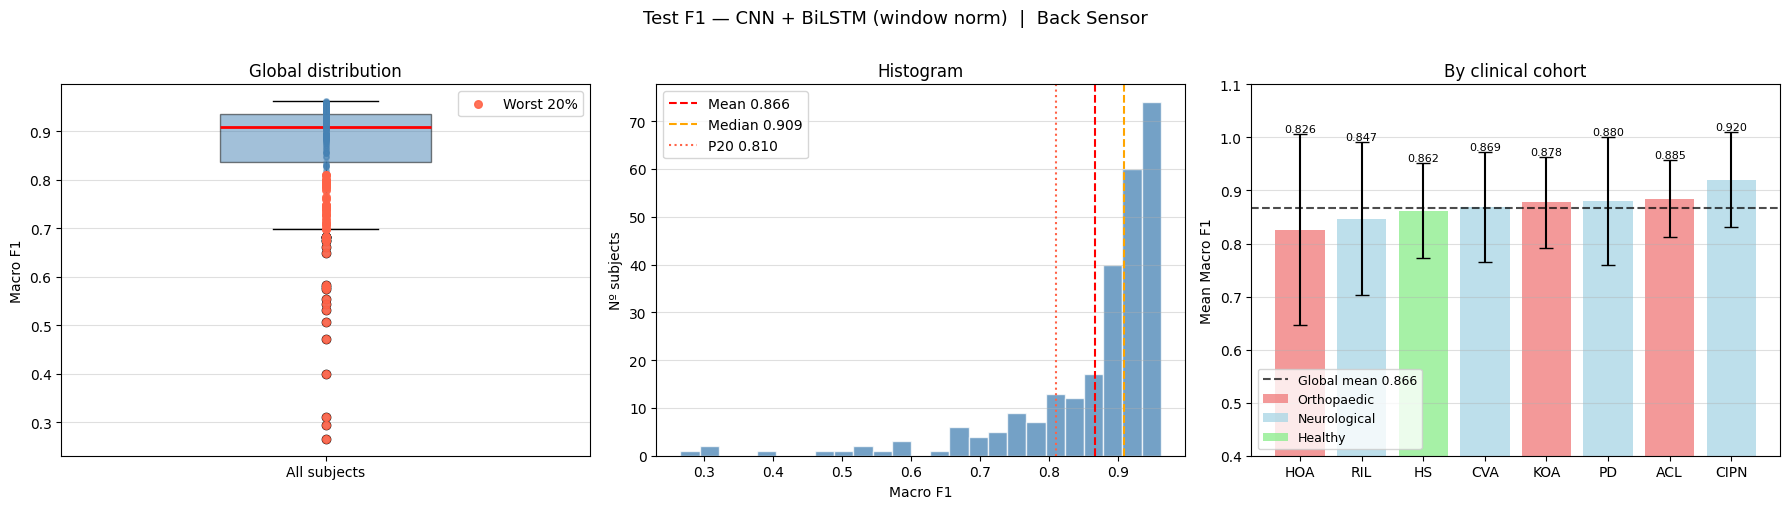


Figure saved in: ../checkpoints/CNNBiLSTM/raw_only_back_window_norm/analysis.png


In [ ]:
statistical_analysis(ckpt_path, "CNN + BiLSTM (window norm)", "Back Sensor")

# Prediction Visualization

In [ ]:
with open(f'{ckpt_path}/summary.json') as f:
    summary = json.load(f)

df_results = pd.DataFrame(summary)

best_idx  = df_results['test_f1'].idxmax()
worst_idx = df_results['test_f1'].idxmin()

best_subj  = df_results.loc[best_idx,  'subject']
worst_subj = df_results.loc[worst_idx, 'subject']

print('Subject with the best score:')
print(df_results.loc[best_idx,  ['subject', 'val_f1', 'test_f1']].to_string())
print()
print('Subject with the worst score:')
print(df_results.loc[worst_idx, ['subject', 'val_f1', 'test_f1']].to_string())

Subject with the best score:
subject       HS_58
val_f1     0.887712
test_f1    0.961732

Subject with the worst score:
subject      RIL_17
val_f1         0.86
test_f1    0.265687


In [ ]:
best_subj_trial = f"{best_subj}_1"  # Obtain first trial of the best classified subject 
worst_subj_trial = f"{worst_subj}_1"  # Obtain first trial of the worst classified subject 

print(best_subj_trial)
print(worst_subj_trial)

HS_58_1
RIL_17_1


In [ ]:
y_pred, y_true, signal = predict_trial(
    base_path   = base_path,
    trial_name  = best_subj_trial,   
    subject     = best_subj,
    model_name  = "cnnbilstm",
    process     = "raw",
    sensors     = ["LB"], 
    window_size = 200,
    stride      = 50,
    out_dir     = ckpt_path
)

print(f"F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

F1: 0.9477


In [ ]:
best_subj_meta = load_trial(base_path, best_subj_trial)
best_subj_meta = best_subj_meta["metadata"] 
best_subj_cohort = best_subj_meta["pathologyKey"] 
best_subj_group = best_subj_meta["group"] 

worst_subj_meta = load_trial(base_path, worst_subj_trial)
worst_subj_meta = worst_subj_meta["metadata"] 
worst_subj_cohort = worst_subj_meta["pathologyKey"] 
worst_subj_group = worst_subj_meta["group"] 

Guardado en: ../checkpoints/CNNBiLSTM/raw_only_back_window_norm/best_subj.png


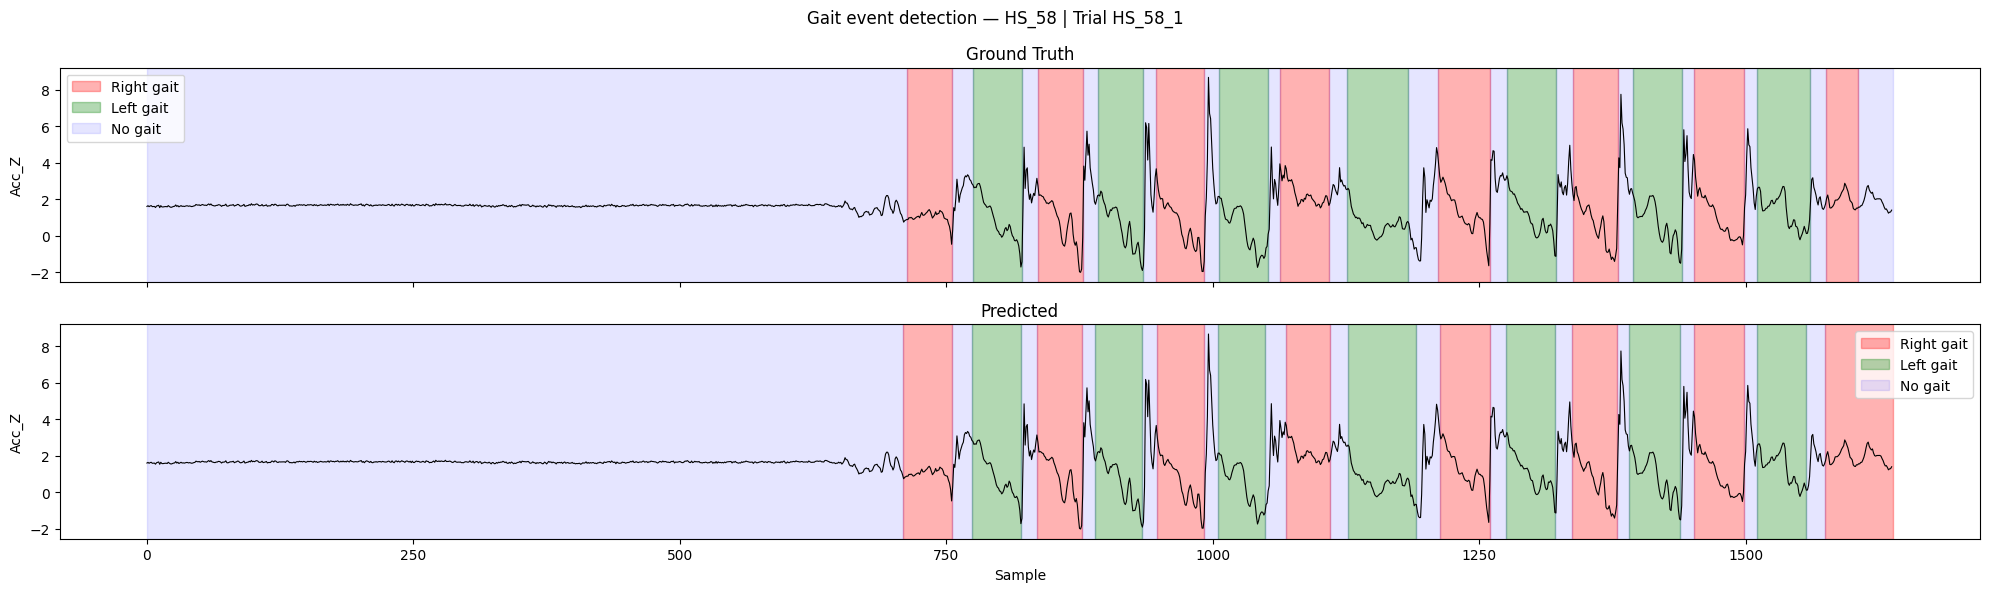

In [ ]:
path = base_path + f"/{best_subj_group}/{best_subj_cohort}/{best_subj}/{best_subj_trial}"

plot_gait_detection(
    y_true, 
    y_pred,
    best_subj_trial,
    path,
    title_base=f'Gait event detection — {best_subj} | Trial {best_subj_trial}',
    sensor='LB',
    signal_channel='Acc_Z',
    process='raw',
    save_path=f'{ckpt_path}/best_subj.png'
)

In [ ]:
y_pred, y_true, signal = predict_trial(
    base_path   = base_path,
    trial_name  = worst_subj_trial,   
    subject     = worst_subj,
    model_name  = "cnnbilstm",
    process     = "raw",
    sensors     = ["LB"],
    window_size = 200,
    stride      = 50,
    out_dir     = ckpt_path
)

print(f"F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

F1: 0.2727


Guardado en: ../checkpoints/CNNBiLSTM/raw_only_back_window_norm/worst_subj.png


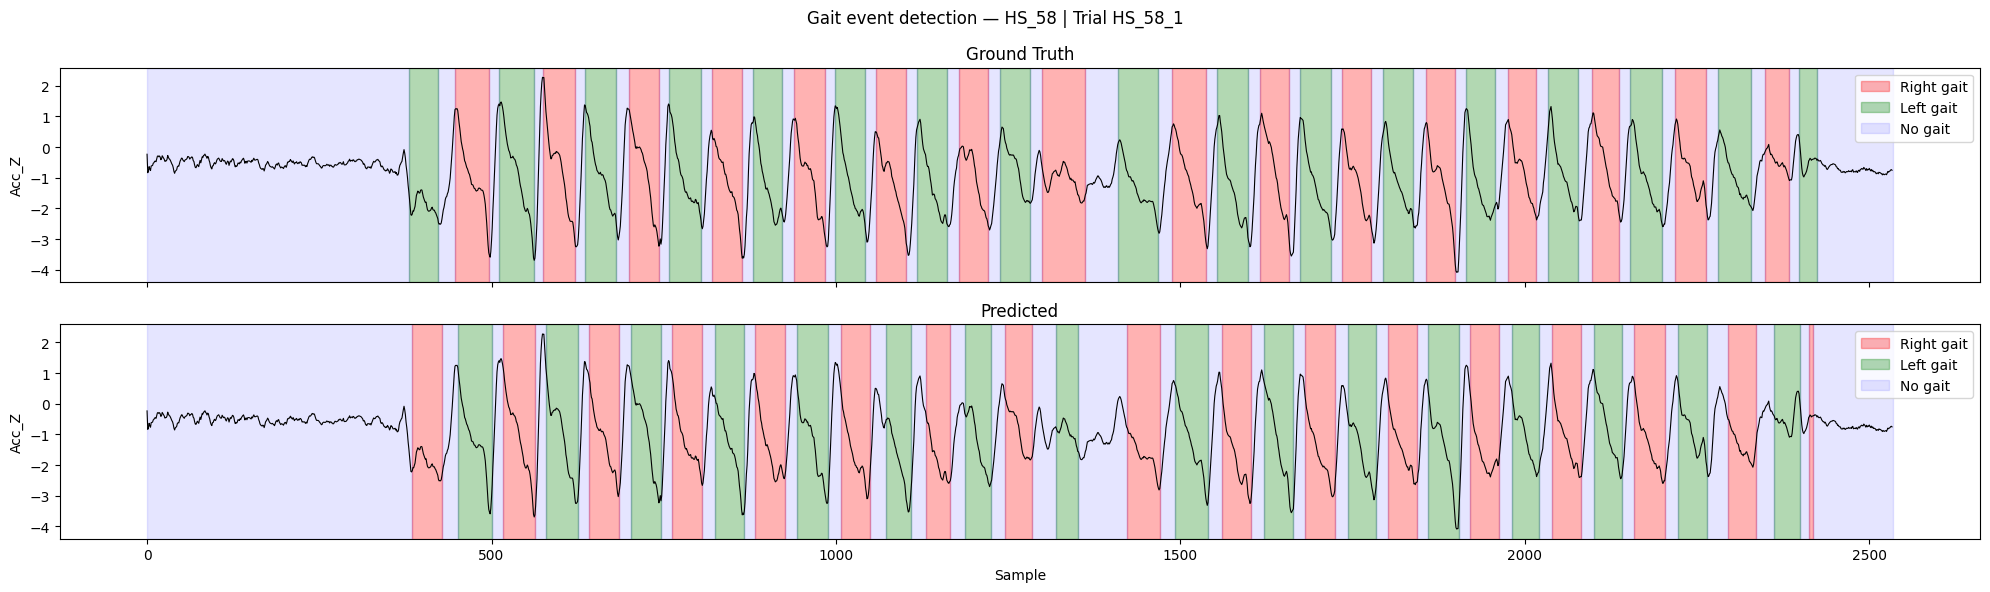

In [ ]:
path = base_path + f"/{worst_subj_group}/{worst_subj_cohort}/{worst_subj}/{worst_subj_trial}"

plot_gait_detection(
    y_true, 
    y_pred,
    worst_subj_trial,
    path,
    title_base=f'Gait event detection — {best_subj} | Trial {best_subj_trial}',
    sensor='LB',
    signal_channel='Acc_Z',
    process='raw',
    save_path=f'{ckpt_path}/worst_subj.png'
)

After applying window normalization, the mean F1 score increased from 0.853 to 0.863. However, the worst subject still shows a very low F1 score (around 0.28).

Visual inspection of the predictions reveals that the model correctly detects the timing of gait events. When a gait event occurs, the prediction aligns closely with the ground truth. However, the model frequently confuses the left and right classes. In other words, left events are often predicted as right events and vice versa, while the no-event class is predicted correctly.

This suggests that the model is capable of detecting the presence of a step but struggles to determine which foot generated the event. This is a common issue that comes from the fact just the lower back sensor is being used. With just this sensor we successfully detect steps but we lack the laterality informaion that would help to correctly classify the most difficult examples.